# Dataset Type

In [1]:
DATASET_TYPE = "downloaded" # Options are "toy" or "downloaded"

# EITHER: Generate the Data

In [2]:
import numpy as np

def generate_dataset():
  n = 5 # degree of the polynomial

  roots = np.random.uniform(-2, 3, n) # Generates random roots for a 5th degree polynomial
  polyCoefficients = np.poly(roots) # Find coefficients of polynomial that has said roots

  x = np.linspace(0, 2, 731)
  y = np.polyval(polyCoefficients, x) # Corresponding Y values passed through polynomial
  return x, y

if DATASET_TYPE == "toy":
  X, Y = generate_dataset()

# OR: Download Real Dataset from UCI Repository

In [3]:
import os
import requests
import zipfile
import pandas as pd
import numpy as np

def download_dataset():
  if (not os.path.exists('Bike-Sharing-Dataset.zip')):
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
    r = requests.get(url)
    open('Bike-Sharing-Dataset.zip', 'wb').write(r.content)

  zf = zipfile.ZipFile('Bike-Sharing-Dataset.zip')
  # Load data from URL using pandas read_csv method
  bike_data_daily = pd.read_csv(zf.open('day.csv'))
  return bike_data_daily.atemp.to_numpy(), bike_data_daily.cnt.to_numpy()

if DATASET_TYPE == "downloaded":
  X, Y = download_dataset()

# Scale the data

In [4]:
# Image processing and pixel values - min-max scaling
# knn-clustering or regression which use distance metrics - standardization
# SVM or logistic regression or Neural Network which use gradiant descent - standardization
# decision tree and random forest - not distance based, hence no scaling is needed

# Normalize the data - Convert to range [0, 1]
# Y = (Y - np.min(Y)) / (np.max(Y) - np.min(Y))
# Standardize the data - Convert to a normal distribution with mean 0 and standard deviation of 1
Y = (Y - np.mean(Y)) / np.std(Y)

# Visualize the Data

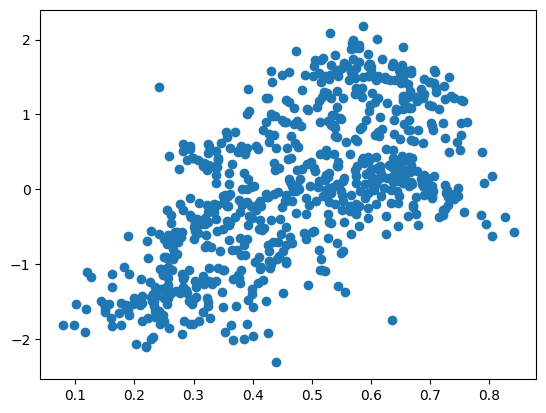

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X, Y)

# Split the Dataset into Training and Test Set

In [8]:
from operator import itemgetter
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Sort x_test

enumerate_x = enumerate(X_test)
sorted_pairs = sorted(enumerate_x, key=itemgetter(1))
sorted_indices = [index for index, element in sorted_pairs]
X_test = sorted(X_test)
Y_test = itemgetter(*sorted_indices)(Y_test)
X_test = np.array(X_test)
Y_test = np.array(Y_test)

# Visualize the Training and Test Data

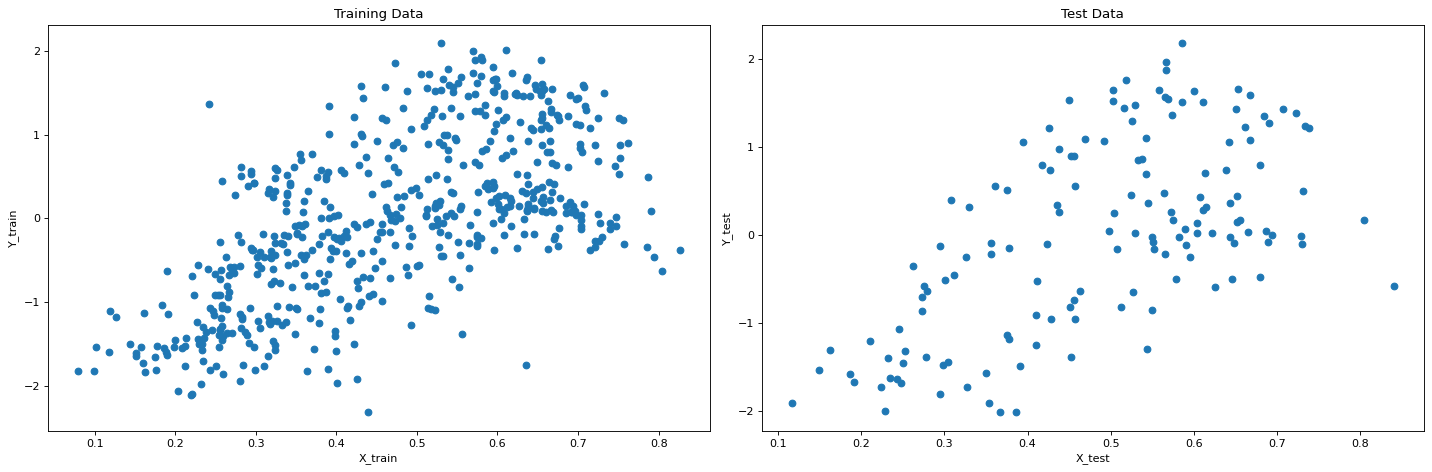

In [9]:
from matplotlib.pyplot import figure

figure(figsize=(18, 6), dpi=80)

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.scatter(X_train, Y_train)
plt.title("Training Data")
plt.xlabel('X_train')
plt.ylabel('Y_train')

plt.subplot(1, 2, 2) # index 2
plt.scatter(X_test, Y_test)
plt.title("Test Data")
plt.xlabel('X_test')
plt.ylabel('Y_test')

plt.tight_layout()
plt.show()

# Initialize the Model

In [11]:
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
X_train.shape, X_test.shape

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDRegressor

# Update hyperparameters for the SGDRegressor function using paraemters defined in -
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

degree=3
polyreg_fit = make_pipeline(PolynomialFeatures(degree), SGDRegressor(alpha = .00001, max_iter=500))

# Train the model

In [12]:
polyreg_fit.fit(X_train, Y_train)

,steps,"[('polynomialfeatures', ...), ('sgdregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,loss,'squared_error'
,penalty,'l2'
,alpha,1e-05


# Run Predictions on Test data

In [ ]:
X_test_sorted = sorted(X_test)

Y_pred = polyreg_fit.predict(X_test_sorted)

# Plot the Predictions

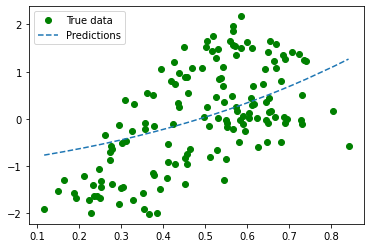

In [ ]:
plt.clf()
plt.plot(X_test, Y_test, 'go', label='True data')
plt.plot(X_test_sorted, Y_pred, '--', label='Predictions')
plt.legend(loc='best')
plt.show()

# Generate the evaluation metrics. Evaluate model quality on Test Data


In [ ]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))

Mean Absolute Error: 0.7579739141597895
Mean Squared Error: 0.7946419563543605
Root Mean Squared Error: 0.8914269214884417


# Overfitting and the bias-variance tradeoff

In [ ]:
# High bias -> less complex model -> underfitting
# High variance -> more complex model -> overfitting

# Less complex model - Fit polynomial with degree 1
degree = 1
polyreg_underfit = make_pipeline(PolynomialFeatures(degree), LinearRegression())
polyreg_underfit.fit(X_train, Y_train)

# More complex model - Fit polynomial with degree 8
degree = 12
polyreg_overfit = make_pipeline(PolynomialFeatures(degree), LinearRegression())
polyreg_overfit.fit(X_train, Y_train)

Pipeline(memory=None,
         steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=12, include_bias=True,
                                    interaction_only=False, order='C')),
                ('sgdregressor',
                 SGDRegressor(alpha=0.0001, average=False, early_stopping=False,
                              epsilon=0.1, eta0=0.01, fit_intercept=True,
                              l1_ratio=0.15, learning_rate='invscaling',
                              loss='squared_loss', max_iter=1000,
                              n_iter_no_change=5, penalty='l2', power_t=0.25,
                              random_state=None, shuffle=True, tol=0.001,
                              validation_fraction=0.1, verbose=0,
                              warm_start=False))],
         verbose=False)

# Plot predictions of all these models on the train and test data

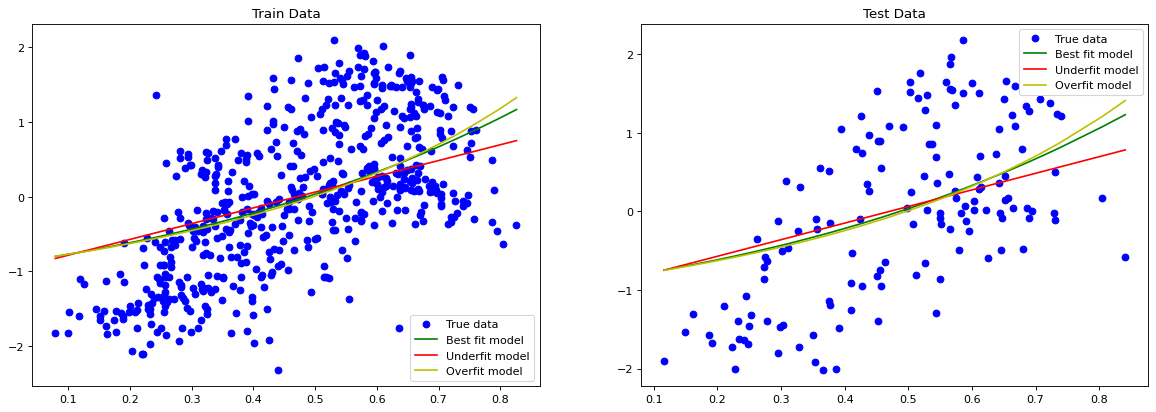

In [ ]:
from matplotlib.pyplot import figure

figure(figsize=(18, 6), dpi=80)

plt.clf()

plt.subplot(1, 2, 1) # row 1, col 2 index 1
plt.plot(X_train, Y_train, 'bo', label='True data')
X_train_sorted = sorted(X_train)

Y_pred_fit = polyreg_fit.predict(X_train_sorted)
Y_pred_underfit = polyreg_underfit.predict(X_train_sorted)
Y_pred_overfit = polyreg_overfit.predict(X_train_sorted)

plt.plot(X_train_sorted, Y_pred_fit, 'g-', label='Best fit model')
plt.plot(X_train_sorted, Y_pred_underfit, 'r-', label='Underfit model')
plt.plot(X_train_sorted, Y_pred_overfit, 'y-', label='Overfit model')
plt.legend(loc='best')
plt.title("Train Data")

plt.subplot(1, 2, 2) # row 1, col 2 index 1
plt.plot(X_test, Y_test, 'bo', label='True data')
X_test_sorted = sorted(X_test)

Y_pred_fit = polyreg_fit.predict(X_test_sorted)
Y_pred_underfit = polyreg_underfit.predict(X_test_sorted)
Y_pred_overfit = polyreg_overfit.predict(X_test_sorted)

plt.plot(X_test_sorted, Y_pred_fit, 'g-', label='Best fit model')
plt.plot(X_test_sorted, Y_pred_underfit, 'r-', label='Underfit model')
plt.plot(X_test_sorted, Y_pred_overfit, 'y-', label='Overfit model')
plt.legend(loc='best')
plt.title("Test Data")


plt.show()

# Evaluate prediction quality of these models on Test Data

In [ ]:
from sklearn import metrics

Y_pred_fit = polyreg_fit.predict(X_test)
Y_pred_underfit = polyreg_underfit.predict(X_test)
Y_pred_overfit = polyreg_overfit.predict(X_test)

print(
      "Mean Absolute Error - Best fit model: ", metrics.mean_absolute_error(Y_test, Y_pred_fit), 
      ", Underfit model: ", metrics.mean_absolute_error(Y_test, Y_pred_underfit), 
      ", Overfit model: ", metrics.mean_absolute_error(Y_test, Y_pred_overfit),
      )
print("Mean Squared Error - Best fit model: ", metrics.mean_squared_error(Y_test, Y_pred_fit), 
      ", Underfit model: ", metrics.mean_squared_error(Y_test, Y_pred_underfit), 
      ", Overfit model: ", metrics.mean_squared_error(Y_test, Y_pred_overfit),
      )
print("Root Mean Squared Error - Best fit model: ", np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_fit)),
      ", Underfit model: ", np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_underfit)),
      ", Overfit model: ", np.sqrt(metrics.mean_squared_error(Y_test, Y_pred_overfit)),
      )

Mean Absolute Error - Best fit model:  0.7596446946443596 , Underfit model:  0.7597544607766564 , Overfit model:  0.7615838066811356
Mean Squared Error - Best fit model:  0.7992694322865381 , Underfit model:  0.8119719568883845 , Overfit model:  0.8072217652155601
Root Mean Squared Error - Best fit model:  0.8940186979513002 , Underfit model:  0.9010948656431156 , Overfit model:  0.898455210467144
